In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fedesoriano/company-bankruptcy-prediction/data.csv


# Company Bankruptcy Prediction (Taiwan, 1999-2009)

## Problem
Predict whether a company goes bankrupt from 95 financial ratios. The dataset (Taiwan Economic Journal) has 6,819 companies, and about 3% of them are bankrupt.

## Method
- Train/test split (80/20)
- Random over-sampling on the **training set only**
- Random forest tuned with grid search
- Re-tuned for F1 instead of accuracy, then lowered the decision threshold to catch more bankruptcies
- Feature importance checked with Gini and permutation importance

## 1. Imports

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split

## 2. Load the data
The CSV is loaded, column names are cleaned, and the label `Bankrupt?` is renamed to `bankrupt`.

In [32]:
import glob
import pandas as pd

path = glob.glob("/kaggle/input/**/data.csv", recursive=True)[0]
print(path)

df = pd.read_csv(path)
df.columns = df.columns.str.strip()
df = df.rename(columns={"Bankrupt?": "bankrupt"})
df["bankrupt"] = df["bankrupt"].astype(bool)
print("df shape:", df.shape)
df.head()

/kaggle/input/datasets/fedesoriano/company-bankruptcy-prediction/data.csv
df shape: (6819, 96)


,bankrupt,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,True,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,True,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,True,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,True,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,True,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## 3. Missing values and class balance
The classes are heavily imbalanced (about 97% not bankrupt), so accuracy alone will be misleading.

Total missing values: 0


<Axes: title={'center': 'Class Balance'}, xlabel='Bankrupt', ylabel='Frequency'>

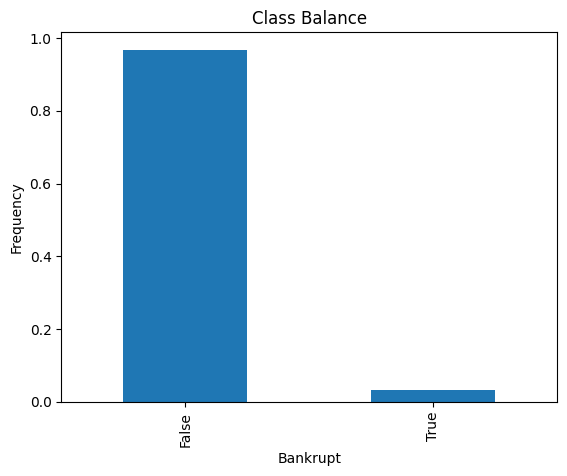

In [33]:
print("Total missing values:", df.isnull().sum().sum())

fig, ax = plt.subplots()
df["bankrupt"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel="Bankrupt",
    ylabel="Frequency",
    title="Class Balance",
    ax=ax,
)

## 4. Features, target, and split
The split happens **before** any resampling so the test set keeps the real class balance.

In [34]:
target = "bankrupt"
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (5455, 95) X_test: (1364, 95)


## 5. Over-sample the training data only
Duplicating bankrupt companies in the training set balances the classes. The test set is left untouched.

In [35]:
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)
print("X_train_over shape:", X_train_over.shape)
print(y_train_over.value_counts())

X_train_over shape: (10572, 95)
bankrupt
False    5286
True     5286
Name: count, dtype: int64


## 6. Baseline and cross-validation
A model that always predicts "not bankrupt" already scores about 0.97 accuracy on the training set, so that is the number to beat. Cross-validation scores here are inflated, because duplicated bankrupt rows land in both training and validation folds.

In [36]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline accuracy:", round(acc_baseline, 4))

clf = RandomForestClassifier(random_state=42)
cv_scores = cross_val_score(clf, X_train_over, y_train_over, cv=5, n_jobs=-1)
print(cv_scores)

Baseline accuracy: 0.969
[0.99196217 0.99479905 0.99479659 0.99668874 0.99479659]


## 7. First model: tuned for accuracy

In [37]:
params = {
    "max_depth": range(30, 50, 10),
    "n_estimators": range(25, 51, 25),
}

model = GridSearchCV(clf, param_grid=params, cv=5, n_jobs=-1, verbose=1)
model.fit(X_train_over, y_train_over)

print(model.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'max_depth': 40, 'n_estimators': 50}


Training accuracy: 1.0
Test accuracy: 0.9663
              precision    recall  f1-score   support

       False       0.97      0.99      0.98      1313
        True       0.59      0.31      0.41        51

    accuracy                           0.97      1364
   macro avg       0.78      0.65      0.70      1364
weighted avg       0.96      0.97      0.96      1364



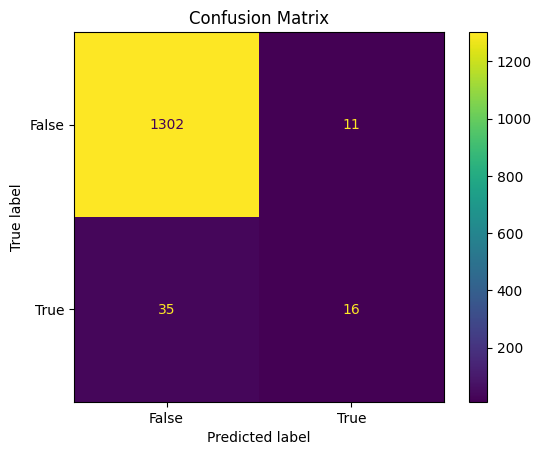

In [38]:
acc_train = model.score(X_train, y_train)
acc_test = model.score(X_test, y_test)
print("Training accuracy:", round(acc_train, 4))
print("Test accuracy:", round(acc_test, 4))

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
ax.set_title("Confusion Matrix")

print(classification_report(y_test, model.predict(X_test)))

**Result:** test accuracy was 0.9663, barely above the test-set baseline of 0.9626 (1,313 of 1,364 companies are not bankrupt). Training accuracy was 1.0, so the forest memorized the training data. Recall on bankrupt companies was only **0.31**: the model missed about 35 of the 51 real bankruptcies. High accuracy was hiding weak performance on the class that matters.

## 8. Second model: tuned for F1 with more regularization
Scoring by F1 and limiting tree depth and leaf size targets the bankrupt class directly and reduces overfitting.

In [39]:
params = {
    "max_depth": [5, 10, 20],
    "n_estimators": [50, 100],
    "min_samples_leaf": [1, 5],
}

model = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    scoring="f1",
    verbose=1,
)
model.fit(X_train_over, y_train_over)
print(model.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}


In [40]:
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

       False       0.98      0.98      0.98      1313
        True       0.46      0.47      0.47        51

    accuracy                           0.96      1364
   macro avg       0.72      0.72      0.72      1364
weighted avg       0.96      0.96      0.96      1364



**Result:** bankrupt-class recall rose from 0.31 to **0.47** and F1 from 0.41 to 0.47. Precision fell from 0.59 to 0.46, meaning more false alarms. Overall accuracy dropped slightly to 0.96, which is expected.

## 9. Lowering the decision threshold
By default a company is flagged as bankrupt when the predicted probability is above 0.5. Lowering the threshold catches more bankruptcies at the cost of more false alarms.

In [41]:
proba = model.predict_proba(X_test)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5]:
    print("Threshold:", t)
    print(classification_report(y_test, proba > t))

Threshold: 0.2
              precision    recall  f1-score   support

       False       0.99      0.94      0.96      1313
        True       0.32      0.73      0.44        51

    accuracy                           0.93      1364
   macro avg       0.65      0.83      0.70      1364
weighted avg       0.96      0.93      0.94      1364

Threshold: 0.3
              precision    recall  f1-score   support

       False       0.99      0.96      0.97      1313
        True       0.37      0.67      0.48        51

    accuracy                           0.95      1364
   macro avg       0.68      0.81      0.73      1364
weighted avg       0.96      0.95      0.95      1364

Threshold: 0.4
              precision    recall  f1-score   support

       False       0.98      0.97      0.98      1313
        True       0.40      0.49      0.44        51

    accuracy                           0.95      1364
   macro avg       0.69      0.73      0.71      1364
weighted avg       0.96      

| Threshold | Precision (bankrupt) | Recall (bankrupt) | F1 (bankrupt) |
|---|---|---|---|
| 0.2 | 0.32 | 0.73 | 0.44 |
| 0.3 | 0.37 | 0.67 | 0.48 |
| 0.4 | 0.40 | 0.49 | 0.44 |
| 0.5 (default) | 0.46 | 0.47 | 0.47 |

**Result:** thresholds between 0.2 and 0.3 work better than the default. At 0.3 the model catches about 34 of 51 bankruptcies (recall 0.67), compared with about 24 at the default, but roughly 6 in 10 flags are false alarms. Choose 0.2 if a missed bankruptcy is much costlier than a false alarm.

## 10. Feature importance (Gini)

Text(0.5, 1.0, 'Feature Importance')

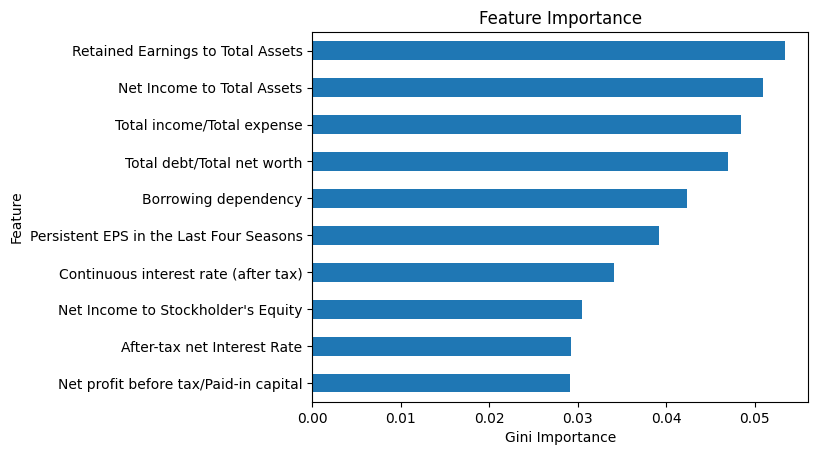

In [42]:
importances = pd.Series(
    model.best_estimator_.feature_importances_, index=X_train.columns
)
top_10 = importances.sort_values().tail(10)

fig, ax = plt.subplots()
top_10.plot(kind="barh", ax=ax)
ax.set_xlabel("Gini Importance")
ax.set_ylabel("Feature")
ax.set_title("Feature Importance")

## 11. Feature importance (permutation)
Permutation importance shuffles one feature at a time on the test set and measures how much the bankrupt-class F1 drops.

In [43]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model.best_estimator_, X_test, y_test,
    scoring="f1", n_repeats=10, random_state=42, n_jobs=-1,
)
perm = pd.DataFrame({
    "mean": result.importances_mean,
    "std": result.importances_std,
}, index=X_test.columns).sort_values("mean", ascending=False)
print(perm.head(10))

                                                       mean       std
Quick Ratio                                        0.099393  0.040464
ROA(B) before interest and depreciation after tax  0.048025  0.027134
Retained Earnings to Total Assets                  0.044784  0.024951
Non-industry income and expenditure/revenue        0.037624  0.032639
Quick Assets/Current Liability                     0.032371  0.023091
Total debt/Total net worth                         0.028514  0.029224
Total income/Total expense                         0.020931  0.016483
Continuous interest rate (after tax)               0.019506  0.015675
Cash Flow to Liability                             0.017471  0.020518
Interest-bearing debt interest rate                0.014803  0.013757


Two importance methods were compared. Gini importance favored profitability measures such as Net Income to Total Assets and Persistent EPS. Permutation importance on the held-out test set (10 repeats, scored by bankrupt-class F1) ranked **Quick Ratio** highest, with a mean drop of about 0.10 and a standard deviation of about 0.04. ROA(B) and Retained Earnings to Total Assets followed, and Retained Earnings to Total Assets was the one feature near the top of both methods. Below the top three, standard deviations are close to the means, so the ranking of those features is uncertain.

## 12. Limitations
- The test set has only 51 bankrupt companies, so metrics move a lot with the random split.
- The threshold was chosen by looking at the test set, so the reported result is slightly optimistic. A cleaner approach is to choose it on a validation split or with cross-validation.
- Many financial ratios are correlated, so importance is shared among them and rankings are approximate.
- Feature importance shows what the model relies on, not what causes bankruptcy.
- Permutation importance was computed at the default 0.5 threshold, not the 0.3 threshold used above.

## Data source
Taiwan Economic Journal, 1999-2009, via the Kaggle dataset "Company Bankruptcy Prediction" (fedesoriano). Original source: UCI Taiwanese Bankruptcy Prediction.